In [1]:
# auto-reload changed source files when they are imported
%reload_ext autoreload
%autoreload 2

# add top repo dir to path so that src can be imported
import sys

# from processing.schnet import model_save_path

sys.path.append("..")

# %matplotlib inline

import os
from datetime import datetime
import copy
from pathlib import Path
import json

import torch
from torch.nn import Linear, ReLU, Dropout
import numpy as np
from torch_geometric.nn import Sequential
from torch_geometric.loader import DataLoader
from src.data.dataset import Crystals
from matplotlib import pyplot as plt
from src.utils.loss import MSELoss, KLDivLoss
from src.models.schnet import SchNet
# from schnetpack.representation import SchNet


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_wavenumbers = np.load('../data/processed/wavenumber_vals_v3.npy')

model = Sequential(
    'z, pos, batch',
    [
        (SchNet(hidden_channels=1024,out_features=256),'z, pos, batch->z'),
        ReLU(inplace=True),
        Dropout(0.5),
        Linear(256, 128),
        ReLU(inplace=True),
        Dropout(0.5),
        Linear(128, len(model_wavenumbers)),
    ]
).to(device)

In [7]:
from tqdm import tqdm
import time
log_dir = 'logs'
now = datetime.now()
dt_string = now.strftime("%Y%m%d-%H%M%S")
dataset_path = '../data/processed/v3.pt'
dataset = Crystals(dataset_path)
save_model_dir = Path(f'models/no/v3 schnet')

train_dataset, val_dataset, test_dataset = dataset.get_splits(deterministic=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
loss_fn = MSELoss()

train_loader = DataLoader(train_dataset, batch_size=256)
val_loader = DataLoader(val_dataset, batch_size=256)

fn = KLDivLoss()
def val(model, val_dataloader):
    model.eval()
    with torch.inference_mode():
        mse = 0
        for data in val_dataloader:
            data = data.to(device)
            pred = model(data.z, data.pos, data.batch)

            mse += fn(pred, data.y)
        return mse / len(val_dataloader)

train_loss = []
val_loss = []
display_epochs = 100
best_model_wts = copy.deepcopy(model.state_dict())
best_val_loss = 0.01
model_save_path = None

In [28]:
def train(model,start,end,lr):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    global model_save_path, best_model_wts, best_val_loss
    try:
        for epoch in tqdm(range(start,end+1)):
            model.train()
            optimizer.zero_grad()
            for data in train_loader:
                data = data.to(device)
                pred = model(data.z, data.pos, data.batch)
                loss = loss_fn(pred, data.y)
                loss.backward()
                optimizer.step()

            train_kl = val(model, train_loader)
            val_kl = val(model, val_loader)
            train_loss.append(train_kl.item())
            val_loss.append(val_kl.item())

            if epoch % display_epochs == 0:
                tqdm.write(f"validation loss: {val_kl.item()}")
                tqdm.write(f"train loss: {train_kl.item()}")
            if val_kl < best_val_loss:
                best_val_loss = val_kl
                best_model_wts = copy.deepcopy(model.state_dict())
                model_save_path = save_model_dir / f'{dt_string}_epoch{epoch:05d}_kl{val_kl:.4f}.pt'
                torch.save(model.state_dict(),model_save_path)
                tqdm.write(f"validation loss: {val_kl.item()}")
                tqdm.write(f"model saved to {model_save_path}")
    except KeyboardInterrupt as e:
        Exception(e)
        tqdm.write(f"validation loss: {val_kl.item()}")
        tqdm.write(f"train loss: {train_kl.item()}")
        return epoch,val_kl,model_save_path,best_model_wts
    return epoch,val_kl,model_save_path,best_model_wts

In [9]:
epoch,val_kl,model_save_path,best_model_wts = train(model,0,1000,lr=1e-5)

  0%|          | 0/1001 [00:01<?, ?it/s]

validation loss: 0.09660850465297699
train loss: 0.08580166846513748


 10%|▉         | 100/1001 [02:45<24:06,  1.61s/it]

validation loss: 0.013302352279424667
train loss: 0.012730133719742298


 20%|█▉        | 200/1001 [05:26<21:16,  1.59s/it]

...

 90%|████████▉ | 900/1001 [24:04<02:40,  1.59s/it]

validation loss: 0.011348187923431396
train loss: 0.01108403317630291


100%|█████████▉| 1000/1001 [26:43<00:01,  1.59s/it]

validation loss: 0.01129116304218769
train loss: 0.011008947156369686


100%|██████████| 1001/1001 [26:43<00:00,  1.60s/it]


In [11]:
epoch,val_kl,model_save_path,best_model_wts = train(model,1000,8500,lr=1e-5)

  0%|          | 0/7501 [00:01<?, ?it/s]

validation loss: 0.011338019743561745
train loss: 0.01106382068246603


  1%|▏         | 100/7501 [02:40<3:16:14,  1.59s/it]

validation loss: 0.011302748695015907
train loss: 0.01113982405513525


  3%|▎         | 200/7501 [05:19<3:13:06,  1.59s/it]

validation loss: 0.011188704520463943
train loss: 0.010895766317844391


  4%|▍         | 300/7501 [07:58<3:11:39,  1.60s/it]

validation loss: 0.011096984148025513
train loss: 0.010786558501422405


  4%|▍         | 318/7501 [08:27<3:10:55,  1.59s/it]

validation loss: 0.011072142980992794
train loss: 0.010771533474326134


In [13]:
epoch,val_kl,model_save_path,best_model_wts = train(model,1300,8500,lr=1e-5)

  0%|          | 0/7201 [00:01<?, ?it/s]

validation loss: 0.011070646345615387
train loss: 0.010772201232612133


  1%|▏         | 100/7201 [02:41<3:08:59,  1.60s/it]

validation loss: 0.01102314330637455
train loss: 0.01069159060716629


  3%|▎         | 200/7201 [05:21<3:06:46,  1.60s/it]

...

validation loss: 0.010139942169189453
train loss: 0.009588981978595257


 11%|█         | 800/7201 [21:23<2:50:39,  1.60s/it]

validation loss: 0.010066395625472069
train loss: 0.009496910497546196


 11%|█▏        | 828/7201 [22:07<2:50:21,  1.60s/it]


TypeError: unsupported operand type(s) for /: 'str' and 'str'

In [19]:
epoch,val_kl,model_save_path,best_model_wts = train(model,2100,8500,lr=1e-5)

  0%|          | 0/6401 [00:01<?, ?it/s]

validation loss: 0.009979713708162308
train loss: 0.00937905814498663


  2%|▏         | 100/6401 [02:44<2:51:09,  1.63s/it]

validation loss: 0.009923512116074562
train loss: 0.0092947818338871


  3%|▎         | 200/6401 [05:27<2:48:58,  1.63s/it]

...

validation loss: 0.008540280163288116
model saved to models\no\v5 schnet\20251107-223547_epoch03774_kl0.0085.pt


 27%|██▋       | 1700/6401 [46:52<2:07:27,  1.63s/it]

validation loss: 0.008605023846030235
train loss: 0.00742613710463047


 27%|██▋       | 1701/6401 [46:52<2:09:32,  1.65s/it]

validation loss: 0.008605023846030235
train loss: 0.00742613710463047


In [22]:
epoch,val_kl,model_save_path,best_model_wts = train(model,3800,8500,lr=1e-5)

  0%|          | 0/4701 [00:01<?, ?it/s]

validation loss: 0.008584309369325638
train loss: 0.007385036442428827


  0%|          | 15/4701 [00:25<2:05:04,  1.60s/it]

validation loss: 0.008533967658877373
model saved to models\no\v3 schnet\20251107-223547_epoch03815_kl0.0085.pt


  0%|          | 16/4701 [00:27<2:09:18,  1.66s/it]

validation loss: 0.008499219082295895
model saved to models\no\v3 schnet\20251107-223547_epoch03816_kl0.0085.pt


  0%|          | 21/4701 [00:35<2:06:16,  1.62s/it]

validation loss: 0.00849706120789051
model saved to models\no\v3 schnet\20251107-223547_epoch03821_kl0.0085.pt


  1%|▏         | 67/4701 [01:50<2:07:46,  1.65s/it]

validation loss: 0.00863499753177166
train loss: 0.007471889723092318


In [27]:
epoch,val_kl,model_save_path,best_model_wts = train(model,3900,8500,lr=1e-5)

  0%|          | 0/4601 [00:01<?, ?it/s]

validation loss: 0.008597669191658497
train loss: 0.007441244088113308


  2%|▏         | 100/4601 [02:42<1:59:14,  1.59s/it]

validation loss: 0.008560331538319588
train loss: 0.007348025683313608


  4%|▍         | 200/4601 [05:21<1:56:34,  1.59s/it]

...

validation loss: 0.0077606989070773125
train loss: 0.00637712562456727


 46%|████▌     | 2110/4601 [56:51<1:07:25,  1.62s/it]

validation loss: 0.007679546717554331
model saved to models\no\v3 schnet\20251107-223547_epoch06010_kl0.0077.pt


 46%|████▌     | 2111/4601 [56:54<1:07:07,  1.62s/it]

validation loss: 0.007688345853239298
train loss: 0.006236322224140167


In [29]:
epoch,val_kl,model_save_path,best_model_wts = train(model,6000,8500,lr=1e-5)

  0%|          | 1/2501 [00:01<55:58,  1.34s/it]

validation loss: 0.00777087826281786
train loss: 0.006381124723702669


  4%|▍         | 100/2501 [01:52<45:40,  1.14s/it]

validation loss: 0.007666807156056166
model saved to models\no\v3 schnet\20251107-223547_epoch06099_kl0.0077.pt


  4%|▍         | 101/2501 [01:53<46:10,  1.15s/it]

...

validation loss: 0.007567794993519783
train loss: 0.006080185994505882


 72%|███████▏  | 1801/2501 [33:44<13:11,  1.13s/it]

validation loss: 0.007444356102496386
train loss: 0.005877575371414423


 73%|███████▎  | 1835/2501 [34:34<12:32,  1.13s/it]

validation loss: 0.007419233210384846
train loss: 0.005899776238948107


In [30]:
epoch,val_kl,model_save_path,best_model_wts = train(model,7800,8500,lr=1e-5)

  0%|          | 1/701 [00:01<18:49,  1.61s/it]

validation loss: 0.0074145179241895676
train loss: 0.005860356613993645


  1%|          | 6/701 [00:07<13:29,  1.16s/it]

validation loss: 0.0073789372108876705
model saved to models\no\v3 schnet\20251107-223547_epoch07805_kl0.0074.pt


  5%|▌         | 36/701 [00:40<12:18,  1.11s/it]

...

validation loss: 0.007308059372007847
model saved to models\no\v3 schnet\20251107-223547_epoch08475_kl0.0073.pt


 97%|█████████▋| 677/701 [12:34<00:27,  1.15s/it]

validation loss: 0.00729310791939497
model saved to models\no\v3 schnet\20251107-223547_epoch08476_kl0.0073.pt


100%|██████████| 701/701 [13:01<00:00,  1.11s/it]

validation loss: 0.0073228515684604645
train loss: 0.005794893484562635


In [31]:
epoch,val_kl,model_save_path,best_model_wts = train(model,8500,10000,lr=1e-5)

  0%|          | 1/1501 [00:01<35:07,  1.40s/it]

validation loss: 0.007370467763394117
train loss: 0.005875728093087673


  1%|          | 10/1501 [00:11<27:56,  1.12s/it]

validation loss: 0.007283609360456467
model saved to models\no\v3 schnet\20251107-223547_epoch08509_kl0.0073.pt


  7%|▋         | 101/1501 [01:52<26:04,  1.12s/it]

...

validation loss: 0.007361375726759434
train loss: 0.005658845417201519


 93%|█████████▎| 1401/1501 [26:17<01:53,  1.13s/it]

validation loss: 0.007254464086145163
train loss: 0.005576715338975191


100%|██████████| 1501/1501 [28:10<00:00,  1.13s/it]

validation loss: 0.007285802625119686
train loss: 0.005640484858304262


0.007341029122471809


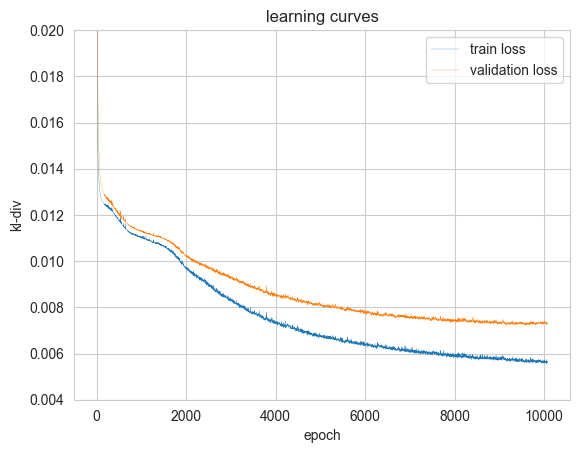

In [37]:
from src.visualization.plotting import plot_spectra, save_all
from src.utils.metrics import kldiv
from matplotlib.ticker import MultipleLocator
import seaborn as sns

sns.set_style("whitegrid")
predict_dir_val = Path(f"predict/v3_schnet/val")
predict_dir_val.mkdir(parents=True,exist_ok=True)
predict_dir_test = Path(f"predict/v3_schnet/test")
predict_dir_test.mkdir(parents=True,exist_ok=True)
loss_dir = Path(f"loss/v3_schnet")
loss_dir.mkdir(parents=True,exist_ok=True)
model_save_path = save_model_dir / f'{dt_string}_epoch{epoch}_kl{val_kl:.4f}.pt'
torch.save(model.state_dict(),model_save_path)

try:

    # best_model =
    # best_model.load_state_dict(best_model_wts)

    param_model = model

    print(kldiv(param_model,device,val_dataset,514,is_schnet=True)[0])
    train_loss_path = loss_dir/"train_kl.json"
    val_loss_path = loss_dir/"val_kl.json"
    train_loss_path.write_text(json.dumps(train_loss,indent=2))
    val_loss_path.write_text(json.dumps(val_loss,indent=2))


    plt.plot(train_loss,linewidth=.2,label="train loss")
    plt.plot(val_loss,linewidth=.2, label="validation loss")
    plt.ylim(0.004,0.02)
    # ax = plt.gca()
    # # ax.yaxis.set_major_locator(MultipleLocator(5e-2))
    plt.title("learning curves")
    plt.ylabel('kl-div')
    plt.xlabel('epoch')
    plt.legend()
    plt.savefig(f"{loss_dir}/loss_kl.png")
    plt.show()
    # save_all(param_model,device,val_dataset,predict_dir_val,is_schnet=True)
except KeyboardInterrupt:
    print("interrupted")